In [64]:
import pandas as pd 

returns = pd.concat([pd.read_parquet("../../data/02_clean/returns_2019.parquet"),
            pd.read_parquet("../../data/02_clean/returns_2020.parquet"),
            pd.read_parquet("../../data/02_clean/returns_2021.parquet")])

cols = returns.loc[:, ~returns.isna().any()].columns
returns = returns[cols]

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# EXPONENTIALLY WEIGHTED CORRELATION WITH SHRINKAGE (from paper)
# ============================================================================

def exponential_weights(t, tau=125):
    """
    Generate exponential weights: w_t = w_0 * exp(-t/tau)
    Normalized so sum(w) = 1
    
    Parameters:
    -----------
    t : int
        Length of time window
    tau : int
        Characteristic time horizon (half-life)
    
    Returns:
    --------
    weights : array
        Exponential weights (most recent = highest weight)
    """
    # Time indices (0 = oldest, t-1 = most recent)
    time_idx = np.arange(t)
    
    # Exponential decay (recent events have higher weight)
    weights = np.exp(-time_idx / tau)
    weights = weights / weights.sum()  # Normalize
    
    # Reverse so most recent has highest weight
    return weights[::-1]


def weighted_correlation(returns, weights):
    """
    Compute weighted Pearson correlation matrix.
    
    Parameters:
    -----------
    returns : DataFrame
        Returns data (rows=time, columns=stocks)
    weights : array
        Time weights (same length as returns)
    
    Returns:
    --------
    corr_matrix : DataFrame
        Weighted correlation matrix
    """
    # Weighted mean
    weighted_mean = (returns * weights[:, None]).sum(axis=0)
    
    # Center the data
    centered = returns - weighted_mean
    
    # Weighted covariance
    weighted_cov = (centered.T @ (centered * weights[:, None])) / weights.sum()
    
    # Convert to correlation
    std = np.sqrt(np.diag(weighted_cov))
    corr = weighted_cov / np.outer(std, std)
    
    return pd.DataFrame(corr, index=returns.columns, columns=returns.columns)


def shrinkage_correlation(corr_matrices):
    """
    Apply shrinkage to average correlation matrix (Eq. 1 from paper).
    
    Averages correlation matrices over time window and shrinks toward
    the grand mean correlation.
    
    Parameters:
    -----------
    corr_matrices : list of DataFrames
        List of correlation matrices over time window
    
    Returns:
    --------
    shrunk_corr : DataFrame
        Shrinkage-adjusted correlation matrix
    """
    # Average the correlation matrices
    avg_corr = sum(corr_matrices) / len(corr_matrices)
    
    # Compute grand mean correlation (off-diagonal only)
    n = len(avg_corr)
    upper_tri_indices = np.triu_indices(n, k=1)
    grand_mean = avg_corr.values[upper_tri_indices].mean()
    
    # Shrinkage formula from paper (Eq. 1)
    shrinkage_factor = 1 / (2 * (len(corr_matrices) + 1))
    
    shrunk = (1 - shrinkage_factor) * avg_corr.values + shrinkage_factor * grand_mean
    
    # Ensure diagonal = 1
    np.fill_diagonal(shrunk, 1.0)
    
    return pd.DataFrame(shrunk, index=avg_corr.index, columns=avg_corr.columns)


# ============================================================================
# DAILY STOCK SELECTION (Top 300 by market cap & performance)
# ============================================================================

def select_stocks_daily(returns, market_caps, t, lookback=250, n_stocks=300):
    """
    Daily stock selection as described in paper:
    1. Top 600 by market cap
    2. Top 300 by performance ratio: mean(return) / std(return)
    
    Parameters:
    -----------
    returns : DataFrame
        Daily returns (index=dates, columns=tickers)
    market_caps : DataFrame
        Market capitalizations (index=dates, columns=tickers)
    t : date or index
        Current day
    lookback : int
        Lookback period for performance calculation (default 250 days = 1 year)
    n_stocks : int
        Number of stocks to select (default 300)
    
    Returns:
    --------
    selected_stocks : list
        List of selected stock tickers
    """
    # Get index position
    if isinstance(t, int):
        t_idx = t
    else:
        t_idx = returns.index.get_loc(t)
    
    # Need enough history
    if t_idx < lookback:
        return []
    
    # Get stocks with sufficient data
    window_returns = returns.iloc[t_idx - lookback:t_idx]
    valid_stocks = window_returns.columns[window_returns.notna().all()]
    
    if len(valid_stocks) < n_stocks:
        return []
    
    # Step 1: Top 600 by market cap at time t
    current_mcap = market_caps.iloc[t_idx][valid_stocks].dropna()
    top_600_by_mcap = current_mcap.nlargest(min(600, len(current_mcap))).index
    
    # Step 2: Compute performance ratio for top 600
    performance_ratios = {}
    
    for stock in top_600_by_mcap:
        stock_returns = window_returns[stock].dropna()
        
        if len(stock_returns) < lookback * 0.8:  # Need at least 80% of data
            continue
        
        mean_return = stock_returns.mean()
        std_return = stock_returns.std()
        
        if std_return > 0:
            performance_ratios[stock] = mean_return / std_return
    
    # Step 3: Top 300 by performance ratio
    performance_df = pd.Series(performance_ratios).sort_values(ascending=False)
    selected_stocks = performance_df.head(n_stocks).index.tolist()
    
    return selected_stocks


# ============================================================================
# ROLLING CORRELATION MATRICES WITH SHRINKAGE
# ============================================================================

def compute_robust_correlations(returns, market_caps=None, 
                                 window_months=6, lookback_year=250,
                                 tau=125, n_stocks=300):
    """
    Compute robust correlation matrices using exponential smoothing + shrinkage.
    
    Parameters:
    -----------
    returns : DataFrame
        Daily returns (index=dates, columns=tickers)
    market_caps : DataFrame, optional
        Market capitalizations for stock selection
    window_months : int
        Correlation estimation window in months (default 6)
    lookback_year : int
        Lookback for stock selection (default 250 days)
    tau : int
        Exponential smoothing parameter (default 125 days)
    n_stocks : int
        Number of stocks to select daily (default 300)
    
    Returns:
    --------
    correlation_matrices : dict
        {date: correlation_matrix} for each trading day
    selected_stocks : dict
        {date: list_of_stocks} for each trading day
    """
    window_days = window_months * 21  # ~125 trading days = 6 months
    
    correlation_matrices = {}
    selected_stocks_dict = {}
    
    # Start from lookback_year + window_days to have enough history
    start_idx = lookback_year + window_days
    
    for t_idx in tqdm(range(start_idx, len(returns)), desc="Computing correlations"):
        t = returns.index[t_idx]
        
        # Select stocks for this day
        if market_caps is not None:
            stocks = select_stocks_daily(returns, market_caps, t_idx, 
                                        lookback=lookback_year, n_stocks=n_stocks)
        else:
            # If no market cap data, use all stocks with sufficient history
            window = returns.iloc[t_idx - lookback_year:t_idx]
            stocks = window.columns[window.notna().all()].tolist()[:n_stocks]
        
        if len(stocks) < 10:  # Need minimum stocks
            continue
        
        selected_stocks_dict[t] = stocks
        
        # Compute exponentially weighted correlations over past 6 months
        corr_matrices_window = []
        
        for s in range(t_idx - window_days, t_idx):
            # Get returns for selected stocks in this window
            window_start = s - window_days
            window_end = s
            
            if window_start < 0:
                continue
            
            window_returns = returns.iloc[window_start:window_end][stocks].dropna()
            
            if len(window_returns) < window_days * 0.5:
                continue
            
            # Exponential weights
            weights = exponential_weights(len(window_returns), tau=tau)
            
            # Weighted correlation
            corr = weighted_correlation(window_returns, weights)
            corr_matrices_window.append(corr)
        
        if len(corr_matrices_window) == 0:
            continue
        
        # Apply shrinkage
        robust_corr = shrinkage_correlation(corr_matrices_window)
        correlation_matrices[t] = robust_corr
    
    return correlation_matrices, selected_stocks_dict


# ============================================================================
# SIMPLIFIED VERSION (if no market cap data)
# ============================================================================

def compute_robust_correlations_simple(returns, window_months=6, tau=125):
    """
    Simplified version: compute robust correlations without stock selection.
    
    Use this if you don't have market cap data.
    """
    window_days = window_months * 21  # ~125 trading days
    
    correlation_matrices = {}
    mst_weight, mst_dist = {}, {}
    
    start_idx = window_days * 2  # Need enough history
    
    for t_idx in tqdm(range(start_idx, len(returns)), desc="Computing correlations and building MSTs"):
        t = returns.index[t_idx]
        
        # Collect correlation matrices over past 6 months
        corr_matrices_window = []
        
        for s in range(t_idx - window_days, t_idx):
            window_start = s - window_days
            window_end = s
            
            if window_start < 0:
                continue
            
            window_returns = returns.iloc[window_start:window_end].dropna(axis=1, how='any')
            
            if len(window_returns) < window_days * 0.5:
                continue
            
            # Exponential weights
            weights = exponential_weights(len(window_returns), tau=tau)
            
            # Weighted correlation
            corr = weighted_correlation(window_returns, weights)
            corr_matrices_window.append(corr)
        
        if len(corr_matrices_window) == 0:
            continue
        
        # Apply shrinkage
        robust_corr = shrinkage_correlation(corr_matrices_window)
        correlation_matrices[t] = robust_corr

        # Build mst graphs
        mst_weight[t], mst_dist[t] = build_mst(robust_corr)
    
    return correlation_matrices, mst_weight, mst_dist

def build_mst(df_corr):
    G_weight = nx.from_pandas_adjacency(df_corr)
    G_dist = nx.from_pandas_adjacency(df_corr)

    for u, v, d in G_weight.edges(data=True):
        d['weight'] = 1 + d['weight']
    
    for u, v, d in G_dist.edges(data=True):
        d['weight'] = np.sqrt(2*(1 - d['weight']))

    mst_weight = nx.minimum_spanning_tree(G_weight, weight='weight')
    mst_dist = nx.minimum_spanning_tree(G_dist, weight="weight")

    return mst_weight, mst_dist


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    # Load your returns data
    returns = pd.concat([pd.read_parquet("../../data/02_clean/returns_2019.parquet"),
            pd.read_parquet("../../data/02_clean/returns_2020.parquet")])

    cols = returns.loc[:, ~returns.isna().any()].columns
    returns = returns[cols]
    
    # Option 1: Simple version (no stock selection)
    print("Computing robust correlations (simple version)...")
    corr_matrices, mst_weight, mst_dist = compute_robust_correlations_simple(
        returns, 
        window_months=6,  # 6-month window as in paper
        tau=125           # Exponential smoothing parameter
    )
    
    print(f"\nComputed {len(corr_matrices)} correlation matrices")
    
    # Option 2: Full version with stock selection (if you have market cap data)
    # market_caps = pd.read_parquet("market_caps.parquet")  # Load your market cap data
    # corr_matrices, selected_stocks = compute_robust_correlations(
    #     returns, 
    #     market_caps=market_caps,
    #     window_months=6,
    #     lookback_year=250,
    #     tau=125,
    #     n_stocks=300
    # )

Computing robust correlations (simple version)...


Computing correlations and building MSTs:   1%|          | 3/252 [00:15<21:20,  5.14s/it]


KeyboardInterrupt: 

In [89]:
mst = {}

for key, corr in tqdm(corr_matrices.items(), desc="Building MSTs"):
    mst[key] = build_mst(corr)

Building MSTs: 100%|██████████| 252/252 [08:16<00:00,  1.97s/it]


In [ ]:
g_temp = next(iter(mst.values()))

degree = pd.Series(dict(g_temp.degree()))
w_degree = pd.Series(dict(g_temp.degree(weight="weight")))

bc = pd.Series(nx.betweenness_centrality(g_temp))
w_bc = pd.Series(nx.betweenness_centrality(g_temp, weight="weight"))

X = (degree + w_degree + bc + w_bc - 4) / 4



AACG   -0.542538
AAOI   -0.627152
AAPL   -0.703471
ABTC    0.210249
ABVC   -0.161841
          ...   
ZKIN   -0.562114
ZTEK   -0.573817
ZUMZ   -0.630787
ZVRA   -0.552251
ZYXI   -0.127266
Length: 710, dtype: float64


Computing autocorrelations at different lags...


Computing autocorrelations: 100%|██████████| 252/252 [00:17<00:00, 14.71it/s]


CORRELATION MATRIX AUTOCORRELATION STATISTICS

Mean autocorrelation by lag:
----------------------------------------
1 day          : 1.0000 ± 0.0000
1 week         : 0.9994 ± 0.0002
1 month        : 0.9899 ± 0.0041
3 months       : 0.9260 ± 0.0304
1 year         : nan ± nan

COMPARISON WITH PAPER (should be ~50% after 1 year):
Our 1-year autocorrelation: nan%
Paper's 1-year autocorrelation: ~50%
Difference: nan%
⚠ WARNING: Lower persistence than expected

PERSISTENCE ANALYSIS:
1 day          : 100.0% of days have autocorr > 50%
1 week         : 100.0% of days have autocorr > 50%
1 month        : 100.0% of days have autocorr > 50%
3 months       : 100.0% of days have autocorr > 50%
1 year         : nan% of days have autocorr > 50%

Generating plots...


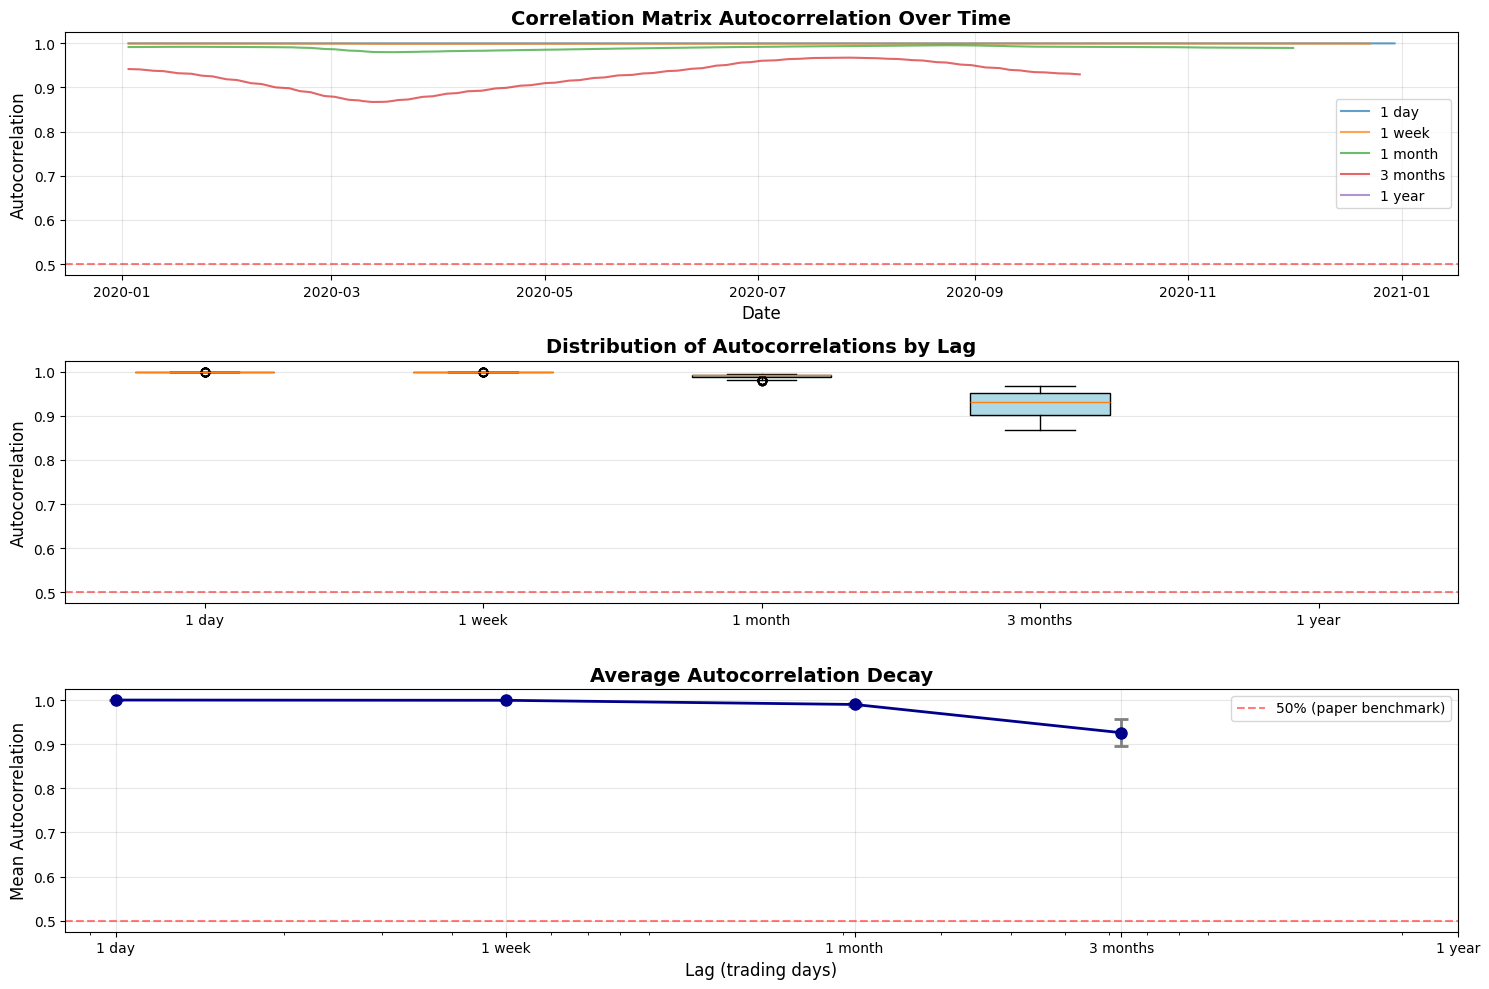


✓ Saved autocorrelation time series to 'correlation_autocorrelations.csv'

ROLLING 3-MONTH AVERAGE AUTOCORRELATIONS:
1 day          : 1.0000
1 week         : 0.9995
1 month        : 0.9925
3 months       : 0.9493
1 year         : nan


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from tqdm import tqdm

# ============================================================================
# CORRELATION MATRIX AUTOCORRELATION
# ============================================================================

def extract_upper_triangular(corr_matrix):
    """
    Extract upper triangular correlation coefficients (excluding diagonal).
    Returns N(N-1)/2 values as a vector.
    """
    n = len(corr_matrix)
    indices = np.triu_indices(n, k=1)  # k=1 excludes diagonal
    return corr_matrix.values[indices]


def compute_correlation_autocorrelation(corr_matrices, lags=[1, 5, 21, 63, 252]):
    """
    Compute autocorrelation of correlation matrices at different time lags.
    
    Parameters:
    -----------
    corr_matrices : dict
        {date: correlation_matrix} for each day
    lags : list
        Time lags to compute autocorrelation (in days)
        Default: [1, 5, 21, 63, 252] = 1 day, 1 week, 1 month, 3 months, 1 year
    
    Returns:
    --------
    autocorr_df : DataFrame
        Autocorrelation values over time for each lag
    """
    dates = sorted(corr_matrices.keys())
    
    # Store results
    results = {f'lag_{lag}d': [] for lag in lags}
    valid_dates = []
    
    for i, t in enumerate(tqdm(dates, desc="Computing autocorrelations")):
        autocorrs = {}
        
        for lag in lags:
            # Find date t+lag
            if i + lag < len(dates):
                t_future = dates[i + lag]
                
                # Extract correlation vectors
                corr_vec_t = extract_upper_triangular(corr_matrices[t])
                corr_vec_future = extract_upper_triangular(corr_matrices[t_future])
                
                # Check if matrices have same dimensions
                if len(corr_vec_t) != len(corr_vec_future):
                    autocorrs[lag] = np.nan
                    continue
                
                # Compute correlation between the two vectors
                if len(corr_vec_t) > 1:
                    autocorr, _ = pearsonr(corr_vec_t, corr_vec_future)
                    autocorrs[lag] = autocorr
                else:
                    autocorrs[lag] = np.nan
            else:
                autocorrs[lag] = np.nan
        
        # Store results
        for lag in lags:
            results[f'lag_{lag}d'].append(autocorrs.get(lag, np.nan))
        valid_dates.append(t)
    
    # Create DataFrame
    autocorr_df = pd.DataFrame(results, index=valid_dates)
    
    return autocorr_df


def plot_autocorrelation_over_time(autocorr_df, figsize=(15, 10)):
    """
    Plot correlation matrix autocorrelation over time.
    
    Parameters:
    -----------
    autocorr_df : DataFrame
        Output from compute_correlation_autocorrelation
    figsize : tuple
        Figure size
    """
    fig, axes = plt.subplots(3, 1, figsize=figsize)
    
    # Extract lag values from column names
    lags = [int(col.split('_')[1].replace('d', '')) for col in autocorr_df.columns]
    lag_labels = {
        1: '1 day',
        5: '1 week',
        21: '1 month',
        63: '3 months',
        252: '1 year'
    }
    
    # Plot 1: All autocorrelations over time
    ax1 = axes[0]
    for col, lag in zip(autocorr_df.columns, lags):
        label = lag_labels.get(lag, f'{lag} days')
        ax1.plot(autocorr_df.index, autocorr_df[col], label=label, alpha=0.7, linewidth=1.5)
    
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Autocorrelation', fontsize=12)
    ax1.set_title('Correlation Matrix Autocorrelation Over Time', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold (paper)')
    
    # Plot 2: Distribution of autocorrelations (boxplot)
    ax2 = axes[1]
    data_for_boxplot = [autocorr_df[col].dropna().values for col in autocorr_df.columns]
    labels_for_boxplot = [lag_labels.get(lag, f'{lag}d') for lag in lags]
    
    bp = ax2.boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax2.set_ylabel('Autocorrelation', fontsize=12)
    ax2.set_title('Distribution of Autocorrelations by Lag', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    
    # Plot 3: Average autocorrelation decay
    ax3 = axes[2]
    avg_autocorr = autocorr_df.mean()
    std_autocorr = autocorr_df.std()
    
    ax3.errorbar(lags, avg_autocorr, yerr=std_autocorr, 
                 marker='o', markersize=8, capsize=5, capthick=2,
                 linewidth=2, color='darkblue', ecolor='gray')
    
    ax3.set_xlabel('Lag (trading days)', fontsize=12)
    ax3.set_ylabel('Mean Autocorrelation', fontsize=12)
    ax3.set_title('Average Autocorrelation Decay', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% (paper benchmark)')
    ax3.set_xscale('log')
    ax3.legend()
    
    # Add lag labels on x-axis
    ax3.set_xticks(lags)
    ax3.set_xticklabels([lag_labels.get(lag, f'{lag}') for lag in lags])
    
    plt.tight_layout()
    plt.savefig('correlation_autocorrelation_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig


def print_autocorrelation_statistics(autocorr_df):
    """
    Print summary statistics for autocorrelations.
    """
    print("="*80)
    print("CORRELATION MATRIX AUTOCORRELATION STATISTICS")
    print("="*80)
    
    print("\nMean autocorrelation by lag:")
    print("-" * 40)
    for col in autocorr_df.columns:
        lag = int(col.split('_')[1].replace('d', ''))
        mean_val = autocorr_df[col].mean()
        std_val = autocorr_df[col].std()
        
        lag_name = {1: '1 day', 5: '1 week', 21: '1 month', 
                   63: '3 months', 252: '1 year'}.get(lag, f'{lag} days')
        
        print(f"{lag_name:15s}: {mean_val:.4f} ± {std_val:.4f}")
    
    print("\n" + "="*80)
    print("COMPARISON WITH PAPER (should be ~50% after 1 year):")
    print("="*80)
    
    if 'lag_252d' in autocorr_df.columns:
        yearly_autocorr = autocorr_df['lag_252d'].mean()
        print(f"Our 1-year autocorrelation: {yearly_autocorr:.2%}")
        print(f"Paper's 1-year autocorrelation: ~50%")
        print(f"Difference: {yearly_autocorr - 0.5:.2%}")
        
        if yearly_autocorr >= 0.45:
            print("✓ GOOD: Correlation matrix shows strong persistence (similar to paper)")
        else:
            print("⚠ WARNING: Lower persistence than expected")
    
    print("\n" + "="*80)
    print("PERSISTENCE ANALYSIS:")
    print("="*80)
    
    # Count how often autocorr > 0.5 for each lag
    for col in autocorr_df.columns:
        lag = int(col.split('_')[1].replace('d', ''))
        pct_above_50 = (autocorr_df[col] > 0.5).sum() / autocorr_df[col].notna().sum() * 100
        
        lag_name = {1: '1 day', 5: '1 week', 21: '1 month', 
                   63: '3 months', 252: '1 year'}.get(lag, f'{lag} days')
        
        print(f"{lag_name:15s}: {pct_above_50:.1f}% of days have autocorr > 50%")


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":   
    # Compute autocorrelations
    print("\nComputing autocorrelations at different lags...")
    autocorr_df = compute_correlation_autocorrelation(
        corr_matrices,
        lags=[1, 5, 21, 63, 252]  # 1d, 1w, 1m, 3m, 1y
    )
    
    # Print statistics
    print_autocorrelation_statistics(autocorr_df)
    
    # Plot
    print("\nGenerating plots...")
    plot_autocorrelation_over_time(autocorr_df)
    
    # Save results
    autocorr_df.to_csv('correlation_autocorrelations.csv')
    print("\n✓ Saved autocorrelation time series to 'correlation_autocorrelations.csv'")
    
    # Additional analysis: Rolling average
    print("\n" + "="*80)
    print("ROLLING 3-MONTH AVERAGE AUTOCORRELATIONS:")
    print("="*80)
    
    rolling_autocorr = autocorr_df.rolling(window=63, min_periods=30).mean()
    
    for col in rolling_autocorr.columns:
        lag = int(col.split('_')[1].replace('d', ''))
        lag_name = {1: '1 day', 5: '1 week', 21: '1 month', 
                   63: '3 months', 252: '1 year'}.get(lag, f'{lag} days')
        
        recent_avg = rolling_autocorr[col].iloc[-63:].mean()  # Last 3 months
        print(f"{lag_name:15s}: {recent_avg:.4f}")